# Project description: Risk prediction of late delivery in Supply Chain
In the fast-paced world of logistics and e-commerce, ensuring packages arrive on schedule is vital for keeping customers happy and operations running smoothly. Whenever a shipment is delayed, it can hurt brand reputation, drive up expenses, and result in lost revenue. Therefore, anticipating and preventing these delays is a top priority for large-scale enterprises.

Drawing inspiration from several successful open-source initiatives and case studies in the supply chain sector, this project focuses on leveraging machine learning to predict shipping delays. Using a comprehensive real-world dataset, the goal is to develop predictive models that accurately flag high-risk orders. A major priority of our approach is to keep false negatives to an absolute minimum—ensuring that almost no delayed shipment slips through the cracks unnoticed.

The dataset driving this analysis includes a wide variety of attributes, such as customer demographics, product categories, shipping schedules, and transaction methods. By digging into this data through statistical analysis and feature engineering, we aimed to uncover the underlying trends and actionable insights that explain why delays happen.

Building upon the methodologies of the projects that inspired this work, we evaluated several algorithms—specifically Random Forest, and XGBoost. To streamline our models and boost efficiency, we applied Recursive Feature Elimination (RFE) to isolate the most impactful variables. Ultimately, the objective is to deliver a reliable forecasting tool that empowers businesses to take proactive steps and guarantee on-time deliveries.

In [1]:
import pandas as pd
import numpy as np
from IPython.core.pylabtools import figsize
from matplotlib.table import table

data = pd.read_csv("data/DataCoSupplyChainDataset.csv", encoding='ISO-8859-1')

data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [2]:
# printing the dimensions
data.shape

(180519, 53)

In [3]:
# making Late_delivery_risk feature proportion
data["Late_delivery_risk"].value_counts(normalize=True)*100

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64

# 1 EDA
In this part I will perform some EDA to explore and understand much in deep the dataset.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

## Sales per delivery status:

In [5]:
# let's see how delivery status are distributed
sales_delivery_status = data.groupby('Delivery Status')['Sales'].sum()
sales_delivery_status

Delivery Status
Advance shipping     8.518008e+06
Late delivery        2.012640e+07
Shipping canceled    1.570305e+06
Shipping on time     6.570026e+06
Name: Sales, dtype: float64

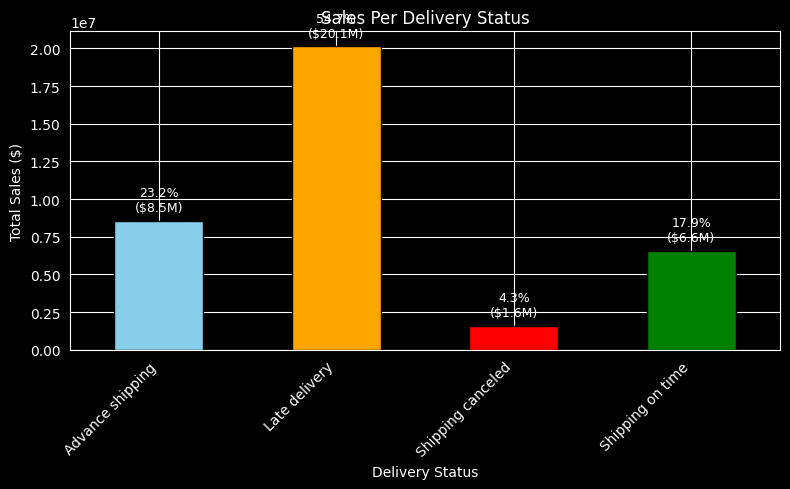

In [7]:
color_mapping = {
    'Shipping canceled': 'red',
    'Shipping on time': 'green',
    'Late delivery': 'orange',
    'Advance shipping': '#87CEEB'
}
colors = [color_mapping.get(status, 'gray') for status in sales_delivery_status.index]


plt.figure(figsize=(8, 5))


ax = sales_delivery_status.plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)

plt.title('Sales Per Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Total Sales ($)')


plt.xticks(rotation=45, ha='right')


total_sales = sales_delivery_status.sum()

for p in ax.patches:
    value = p.get_height()
    percentage = (value / total_sales) * 100


    label_text = f'{percentage:.1f}%\n(${value/1e6:.1f}M)'


    ax.annotate(
        label_text,
        (p.get_x() + p.get_width() / 2., value),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=9
    )


plt.tight_layout()
plt.show()

This visualization illustrates the distribution of sales across different delivery outcomes. Notably, more than half of the total sales (54.7%) are linked to delayed shipments, highlighting a critical operational bottleneck that poses a serious risk to customer loyalty.

On the positive side, early deliveries account for 23.2% of sales, reflecting a degree of logistical efficiency, while strictly on-time shipments make up 17.9%. Additionally, cancellations represent 4.3% of the total, pointing to a tangible loss in potential revenue.

Overall, the overwhelming proportion of late deliveries indicates that optimizing the fulfillment process is essential to elevate the customer experience and mitigate ongoing business risks.

## Sales per market

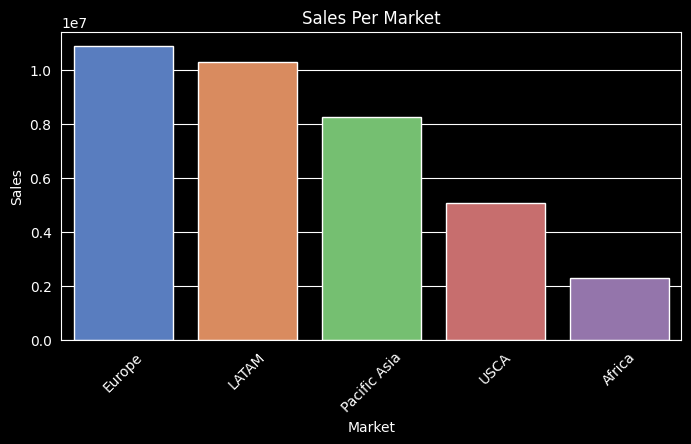

In [8]:
sales_market = data.groupby('Market')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=sales_market.index, y=sales_market.values, palette='muted')
plt.title('Sales Per Market')
plt.xlabel('Market')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

## TOP 10 Regions with LOSS

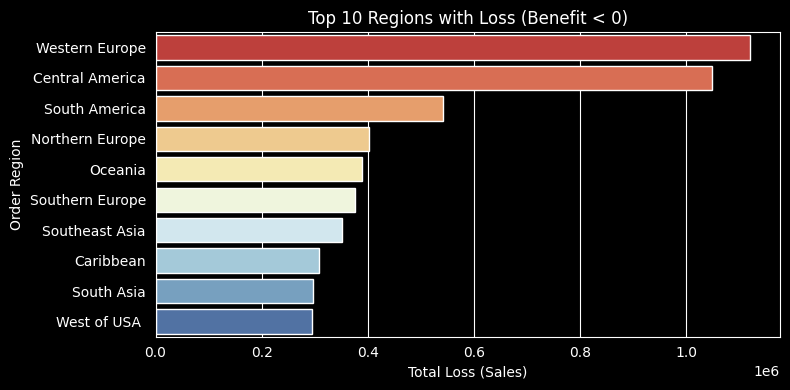

In [9]:
regions_with_loss = data[data['Benefit per order'] < 0].groupby('Order Region')['Sales'].sum().sort_values(ascending=False)

top_10_loss = regions_with_loss.head(10)

plt.figure(figsize=(8,4))

sns.barplot(
    x=top_10_loss.values,
    y=top_10_loss.index,
    palette='RdYlBu'
)
plt.title('Top 10 Regions with Loss (Benefit < 0)')
plt.xlabel('Total Loss (Sales)')
plt.tight_layout()
plt.show()

#### Regional Sales Performance
When evaluating global revenue, Europe emerges as the top-performing market, with Latin America (LATAM) following closely behind. Pacific Asia also accounts for a substantial portion of total sales, though it trails the top two leaders. Further down, the USCA region generates more moderate revenue, while Africa represents the smallest market share. These clear geographical disparities suggest varying market capacities, distinct customer demographics, or differing levels of logistical efficiency across each territory.

#### Analysis of Regional Losses
On the operational loss front, Western Europe experiences the highest financial drain, closely mirrored by Central and South America. Other areas—specifically Northern Europe, Oceania, and Southern Europe—also report notable deficits, albeit to a lesser extent. Conversely, regions such as Southeast Asia, the Caribbean, South Asia, and the Western United States record the lowest financial impacts. Ultimately, these regional insights provide a critical foundation for leadership to pinpoint the root causes of inefficiencies and to implement targeted, cost-saving strategies where they are needed most.

### TOP 10 SALES PER PRODUCT CATEGORY:

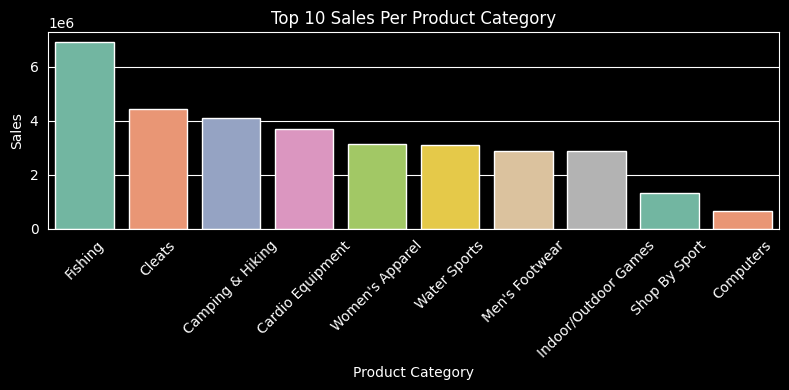

In [10]:

sales_per_category = data.groupby('Category Name')['Sales'].sum().sort_values(ascending=False)



top_10_sales_per_category = sales_per_category.head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_10_sales_per_category.index, y=top_10_sales_per_category.values, palette='Set2')
plt.title('Top 10 Sales Per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### TOP 10 PRODUCTS WITH LOSS:

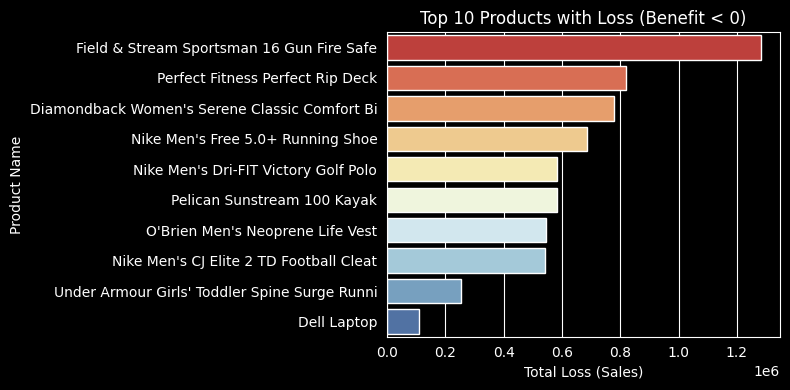

In [11]:
top_10_products_loss = data[data['Benefit per order'] < 0].groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=top_10_products_loss.values,
    y=top_10_products_loss.index,
    palette='RdYlBu'
)
plt.title('Top 10 Products with Loss (Benefit < 0)')
plt.xlabel('Total Loss (Sales)')
plt.tight_layout()
plt.show()

### NUMBER OF ORDERS FROM DIFFERENT DEPARTMENTS VS SHIPPING MODE:

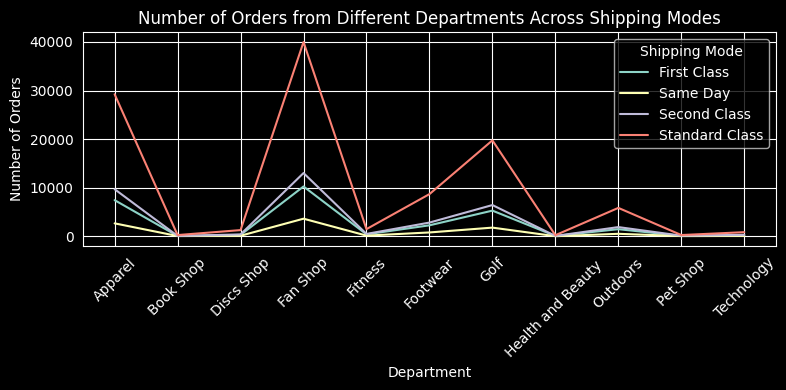

In [12]:
category_shipping = data.groupby(['Department Name', 'Shipping Mode']).size().unstack(fill_value=0)

plt.figure(figsize=(8,4))
for mode in category_shipping.columns:
    plt.plot(category_shipping.index, category_shipping[mode], label=mode)

plt.xlabel('Department')
plt.ylabel('Number of Orders')
plt.title('Number of Orders from Different Departments Across Shipping Modes')
plt.xticks(rotation=45)


plt.legend(title='Shipping Mode')


plt.tight_layout()
plt.show()

This visualization illustrates order volumes across various departments, categorized by shipping method. Standard Class emerges as the overwhelming favorite across the board, experiencing notable volume spikes within the Fan Shop, Disc Shop, and Outdoors categories.

While Second Class ranks as the next most popular choice, its adoption rate is substantially lower than the standard option. In contrast, premium tiers like First Class and Same Day delivery see minimal usage across all product lines.

Ultimately, this trend reveals a strong overarching consumer preference for standard shipping—likely driven by cost considerations—with expedited delivery services remaining a niche choice regardless of the department.

### LATE DELIVERIES VS. SHIPPING MODE VS. REGION:

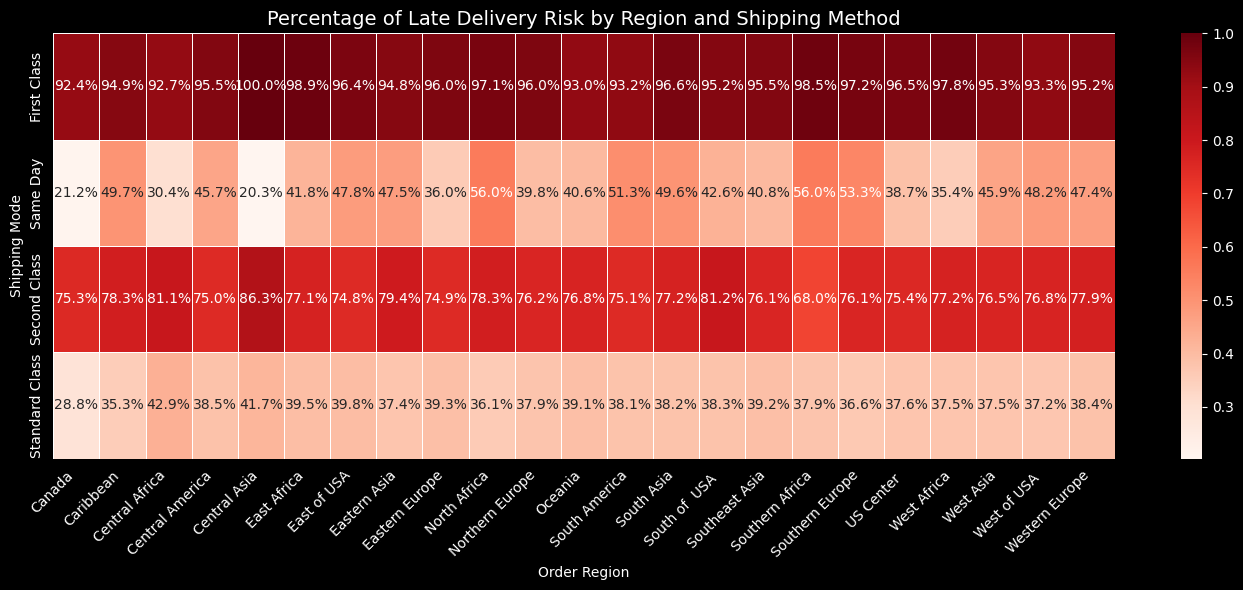

In [15]:
pivot_risk = data.pivot_table(
    index='Shipping Mode',
    columns='Order Region',
    values='Late_delivery_risk',
    aggfunc='mean'
)

# Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_risk,
    annot=True,
    fmt=".1%",
    cmap="Reds",
    linewidths=.5
)

plt.title('Percentage of Late Delivery Risk by Region and Shipping Method', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Turning our attention to this heatmap, we are looking at the percentage of late delivery risk broken down by shipping method on the vertical axis, and the order region along the horizontal axis. The darker the red, the higher the risk of a package arriving late.

Right away, the most striking takeaway jumps out at the top of the chart: our premium shipping options are severely underperforming. If you look at the First Class row, it’s a solid block of dark red. We are seeing late delivery risks ranging from 92% to an absolute 100% in regions like Central Asia. Second Class shipping isn't doing much better, consistently hovering between 74% and 86% across all global markets. Essentially, customers who are paying a premium for faster shipping are almost guaranteed to experience a delay.

Conversely, if we look down at the bottom row, we see a highly counter-intuitive trend. Standard Class—our slowest shipping method—is actually our most reliable. The lighter shading indicates a much lower and highly stable risk of delay, generally sitting between 35% and 42%, regardless of where in the world the package is going.

Finally, Same Day delivery presents a completely mixed picture. Notice how the colors fluctuate wildly in that row. In markets like Canada and Central Asia, it performs exceptionally well, with risks around 20% to 21%. However, in regions like Southeast Asia and North Africa, the risk spikes to 56%. This tells us that our same-day fulfillment success is heavily dependent on local infrastructure rather than a standardized global process.

Ultimately, what this visual clearly highlights is that our logistical bottlenecks are tied to the shipping modes rather than the geography. Moving forward, fixing the fulfillment pipeline for our First and Second Class tiers needs to be an urgent priority to protect customer satisfaction.

### SHIPPING DAYS VS. SHIPPING MODE

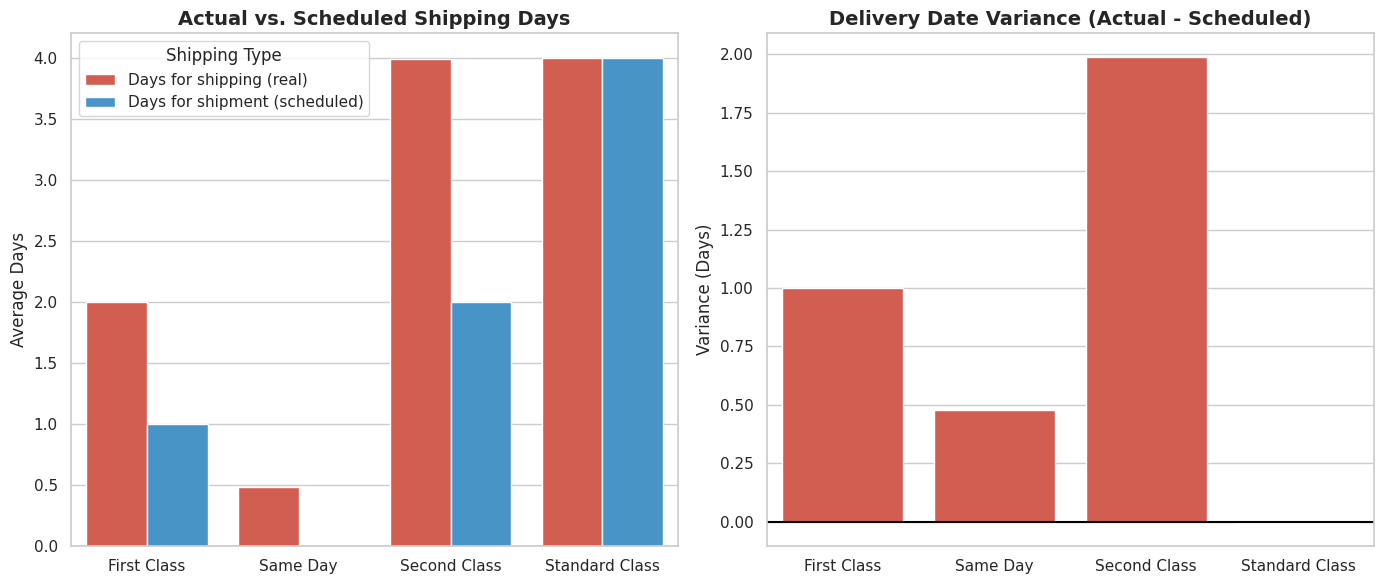

In [16]:
shipping_days = data.groupby('Shipping Mode').agg({
    'Days for shipping (real)': 'mean',
    'Days for shipment (scheduled)': 'mean'
}).reset_index()

shipping_days['Delivery Date Variance'] = shipping_days['Days for shipping (real)'] - shipping_days['Days for shipment (scheduled)']

melted_days = pd.melt(
    shipping_days,
    id_vars=['Shipping Mode'],
    value_vars=['Days for shipping (real)', 'Days for shipment (scheduled)'],
    var_name='Shipping Type',
    value_name='Average Days'
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- PLOT 1: (Actual vs Scheduled)
sns.barplot(
    data=melted_days,
    x='Shipping Mode',
    y='Average Days',
    hue='Shipping Type',
    ax=axes[0],
    palette=['#e74c3c', '#3498db']
)
axes[0].set_title('Actual vs. Scheduled Shipping Days', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Days')
axes[0].set_xlabel('')

# --- PLOT 2: Variance with conditional colors
variance_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in shipping_days['Delivery Date Variance']]

sns.barplot(
    x=shipping_days['Shipping Mode'],
    y=shipping_days['Delivery Date Variance'],
    ax=axes[1],
    palette=variance_colors,
    hue=shipping_days['Shipping Mode'],
    legend=False
)
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].set_title('Delivery Date Variance (Actual - Scheduled)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Variance (Days)')
axes[1].set_xlabel('')


plt.tight_layout()
plt.show()

Looking closely at these two charts, I can clearly identify a major systemic issue with how we are handling our premium shipping options. Let me break down exactly what I am seeing from this data.

1. The "Premium" Shipping Illusion
The most alarming insight comes from looking at Second Class shipping. On the left chart, we can see that we schedule Second Class deliveries to take 2 days, but in reality, they take an average of 4 days.
What makes this a critical business problem is that Standard Class also takes exactly 4 days in reality (which matches its 4-day schedule). Essentially, our customers are likely paying extra for Second Class shipping, but receiving their packages in the exact same timeframe as those who chose the cheaper Standard option.

2. Consistent Delays Across Faster Methods
When we look at the "Delivery Date Variance" chart on the right, it paints a clear picture of broken promises:

    * Second Class is our worst offender, consistently arriving 2 full days late on average.

    * First Class is scheduled for 1 day but takes 2, resulting in a consistent 1-day delay (a 100% margin of error).

    * Same Day shipping is also missing its mark, showing a variance of about half a day late.

3. Standard Class is Our Only Reliable Method
The only positive takeaway we see here is the performance of Standard Class. Looking at the left chart, the actual days perfectly match the scheduled days (4 days). On the right chart, its variance is exactly zero. It is the only shipping method where we are actually keeping our promise to the customer.

# 2 Correlation Analysis

In [17]:
#let's print out the numerical data
numerical_data = data.select_dtypes(include=['number']).copy()
numerical_data.head()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
0,3,4,91.250000,314.640015,0,73,20755,725.0,2,18.251453,...,1,327.75,314.640015,91.250000,NaN,1360,73,NaN,327.75,0
1,5,4,-249.089996,311.359985,1,73,19492,725.0,2,18.279451,...,1,327.75,311.359985,-249.089996,NaN,1360,73,NaN,327.75,0
2,4,4,-247.779999,309.720001,0,73,19491,95125.0,2,37.292233,...,1,327.75,309.720001,-247.779999,NaN,1360,73,NaN,327.75,0
3,3,4,22.860001,304.809998,0,73,19490,90027.0,2,34.125946,...,1,327.75,304.809998,22.860001,NaN,1360,73,NaN,327.75,0
4,2,4,134.210007,298.250000,0,73,19489,725.0,2,18.253769,...,1,327.75,298.250000,134.210007,NaN,1360,73,NaN,327.75,0


In [18]:
# let's examine the Pearson correlation
corr_pearson = numerical_data.corr(method='pearson')
corr_pearson

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
Days for shipping (real),1.000000,0.515880,-0.005101,0.001757,0.401415,-0.000348,0.003432,0.000112,-0.001631,-0.004073,...,-0.000811,0.001962,0.001757,-0.005101,-0.000811,-0.000859,-0.000348,NaN,0.002185,NaN
Days for shipment (scheduled),0.515880,1.000000,-0.000185,0.006445,-0.369352,-0.000367,0.000899,-0.003019,-0.000262,-0.005300,...,-0.002925,0.006327,0.006445,-0.000185,0.005249,-0.000431,-0.000367,NaN,0.006912,NaN
Benefit per order,-0.005101,-0.000185,1.000000,0.133484,-0.003727,0.031889,0.009354,0.002235,0.031442,0.000338,...,0.015696,0.131816,0.133484,1.000000,-0.004978,0.033161,0.031889,NaN,0.103459,NaN
Sales per customer,0.001757,0.006445,0.133484,1.000000,-0.003791,0.225201,0.060181,-0.001304,0.232367,-0.000223,...,0.105413,0.989744,1.000000,0.133484,-0.000138,0.236367,0.225201,NaN,0.781781,NaN
Late_delivery_risk,0.401415,-0.369352,-0.003727,-0.003791,1.000000,0.001752,0.001484,0.003148,0.001077,0.000679,...,-0.000139,-0.003564,-0.003791,-0.003727,-0.014131,0.001490,0.001752,NaN,-0.002175,NaN
Category Id,-0.000348,-0.000367,0.031889,0.225201,0.001752,1.000000,0.274633,0.002898,0.888835,0.002195,...,-0.302408,0.227483,0.225201,0.031889,-0.005943,0.991092,1.000000,NaN,0.461059,NaN
Customer Id,0.003432,0.000899,0.009354,0.060181,0.001484,0.274633,1.000000,0.002022,0.136897,0.002335,...,-0.091328,0.060961,0.060181,0.009354,-0.005659,0.228039,0.274633,NaN,0.111118,NaN
Customer Zipcode,0.000112,-0.003019,0.002235,-0.001304,0.003148,0.002898,0.002022,1.000000,0.002878,0.584553,...,-0.006174,-0.001490,-0.001304,0.002235,0.011843,0.003173,0.002898,NaN,0.002191,NaN
Department Id,-0.001631,-0.000262,0.031442,0.232367,0.001077,0.888835,0.136897,0.002878,1.000000,0.002460,...,-0.265437,0.234718,0.232367,0.031442,-0.005982,0.906117,0.888835,NaN,0.446743,NaN
Latitude,-0.004073,-0.005300,0.000338,-0.000223,0.000679,0.002195,0.002335,0.584553,0.002460,1.000000,...,-0.001853,-0.000696,-0.000223,0.000338,-0.002921,0.002031,0.002195,NaN,0.000471,NaN


In [19]:
# now we select only the Late_delivery_risk column
corr_pearson['Late_delivery_risk'].sort_values(ascending=False)

Late_delivery_risk               1.000000
Days for shipping (real)         0.401415
Customer Zipcode                 0.003148
Category Id                      0.001752
Product Category Id              0.001752
Order Item Cardprod Id           0.001490
Product Card Id                  0.001490
Order Customer Id                0.001484
Customer Id                      0.001484
Department Id                    0.001077
Latitude                         0.000679
Order Item Discount Rate         0.000404
Order Item Quantity             -0.000139
Order Item Discount             -0.000750
Order Id                        -0.001293
Order Item Id                   -0.001376
Longitude                       -0.001915
Product Price                   -0.002175
Order Item Product Price        -0.002175
Order Item Profit Ratio         -0.002316
Sales                           -0.003564
Benefit per order               -0.003727
Order Profit Per Order          -0.003727
Order Item Total                -0

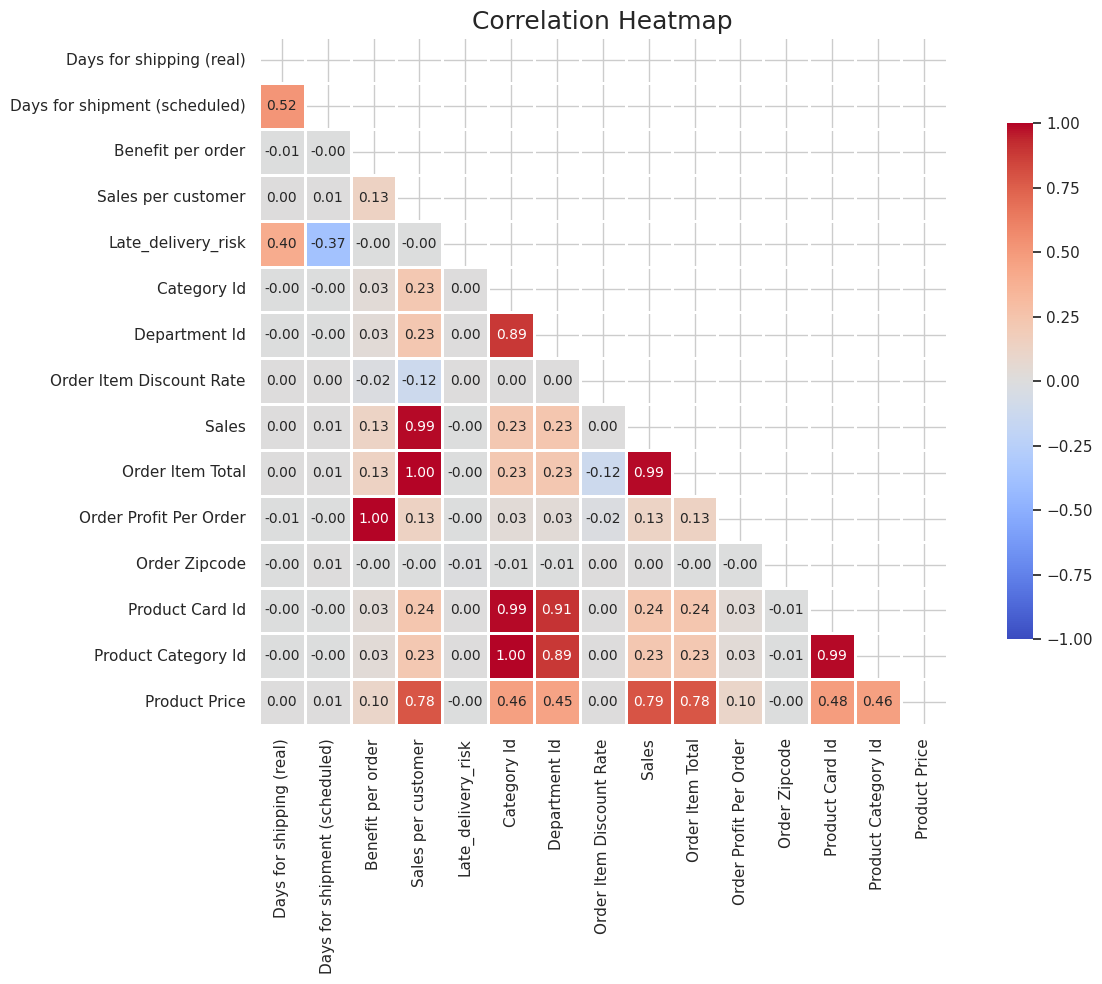

In [20]:
# we are ready to print the correlation heatmap
columns_to_drop = [
    'Customer Id', 'Customer Zipcode', 'Latitude', 'Longitude', 'Order Customer Id',
    'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Id',
    'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity',
    'Product Description', 'Product Status'
]

numerical_df_clean = numerical_data.drop(columns=columns_to_drop)

corr_pearson = numerical_df_clean.corr()

plt.figure(figsize=(14, 10))

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,       # Forces the minimum color to represent -1 (perfect negative correlation)
    vmax=1,        # Forces the maximum color to represent +1 (perfect positive correlation)
    mask=mask,
    square=True,
    annot_kws={"size": 10}, # slightly smaller text helps if you have many columns
    cbar_kws={"shrink": 0.75},
    linewidths=1
)

plt.title('Correlation Heatmap', fontsize=18)


plt.tight_layout()
plt.show()

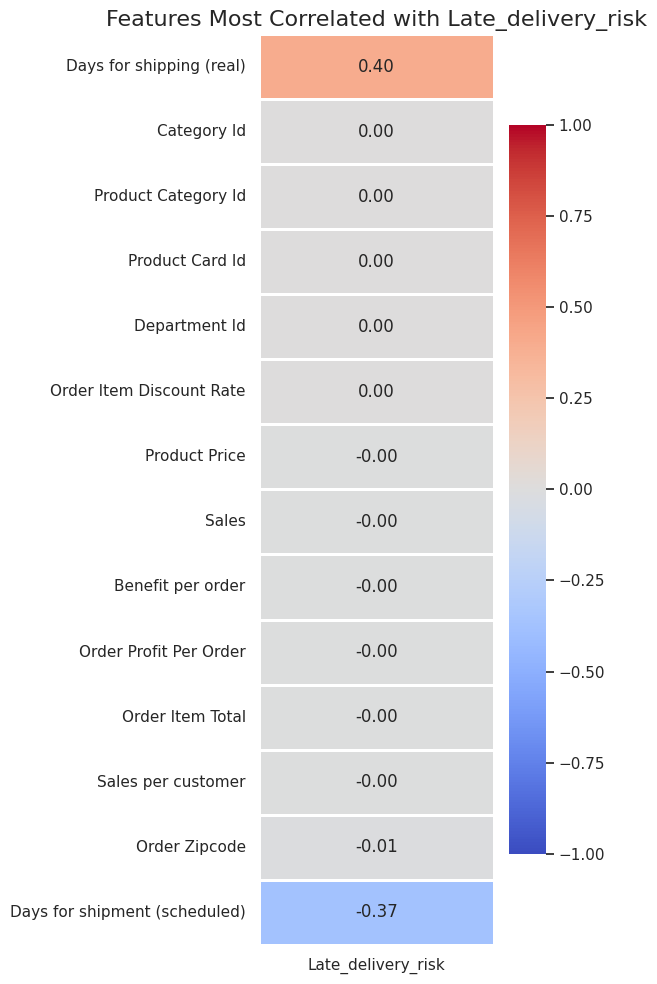

In [21]:
# Let's say your main goal is to predict 'Late_delivery_risk'
target_var = 'Late_delivery_risk' # Change this to your actual target column name

# 1. Calculate correlations, isolate the target column, and sort it
corr_with_target = numerical_df_clean.corr()[[target_var]].sort_values(by=target_var, ascending=False)

# 2. Drop the target variable's correlation with itself (which is always 1.0)
corr_with_target = corr_with_target.drop(target_var)

# 3. Plot a single-column heatmap
plt.figure(figsize=(6, 10)) # Narrow width, tall height
sns.heatmap(
    corr_with_target,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

plt.title(f'Features Most Correlated with {target_var}', fontsize=16)
plt.tight_layout()
plt.show()

### Correlation Analysis: What Really Drives Late Deliveries?

Looking at these correlation heatmaps, my primary goal was to understand which numerical features impact our late deliveries and to check the overall health of our dataset before feeding it into a machine learning model.

####  1. Financials and Products Don't Cause Delays
When I isolated our target variable, Late_delivery_risk, in the single-column heatmap, the results were striking. Almost none of the financial or product-related metrics—like Sales, Order Profit Per Order, or Product Price—have any linear correlation (0.00) with delayed deliveries. This is a valuable business insight: an expensive, high-profit order is just as likely to be delayed as a cheap one.

#### 2. The Schedule is the Bottleneck
The only two variables that show a meaningful relationship with our target are entirely time-based. Days for shipping (real) has a positive correlation (0.40), while Days for shipment (scheduled) has a negative correlation (-0.37). This mathematically backs up my earlier findings: the shorter the scheduled delivery window (like Same Day or First Class), the higher the mathematical probability of it being flagged as a late delivery.

#### 3. Identifying Redundant Features (Multicollinearity)
Taking a step back to look at the full triangular heatmap, I also noticed massive multicollinearity among the other variables. For example, Sales and Order Item Total are perfectly correlated (1.00), meaning they represent the exact same information. The same applies to Category Id, Product Category Id, and Department Id (correlations ranging from 0.89 to 1.00).

#### Next Steps for the ML Model:
These charts give me a clear direction for the modeling phase. Because the financial metrics have zero linear correlation with delays, tree-based models (like Random Forest or XGBoost) will likely perform better than simple Logistic Regression, as they can capture non-linear patterns. Furthermore, I will definitely need to drop the redundant ID and Sales columns to reduce noise and prevent my model from overfitting.

# 3 Data Cleaning

### Missing Values

In [23]:
# let's print the NULLs
data.isnull().sum().sort_values(ascending=False)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
Customer Password                     0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Days for shipping (real)              0
Type                                  0
Department Id                         0
Customer Street                       0
Department Name                       0
Latitude                              0


In [24]:
data.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [25]:
# for our purpose we can drop the following columns

columns_to_drop = ['Order Zipcode', 'Product Description', 'Customer Id', 'Order Id', 'Product Card Id',
                   'Latitude', 'Longitude', 'Customer Email', 'Customer Fname',
                   'Customer Lname', 'Customer Password', 'Customer Street',
                   'Order Item Cardprod Id', 'Order Customer Id',
                   'Product Image', 'Product Name', 'Category Name', 'Customer State',
                   'Customer Zipcode', 'Department Name']


data_clean = data.drop(columns=columns_to_drop)

### Outliers

In [26]:
# performing the same steps as before because we drop different data
numerical_data = data_clean.select_dtypes(include=['number']).copy()
numerical_data.head()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Department Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Category Id,Product Price,Product Status
0,3,4,91.250000,314.640015,0,73,2,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,73,327.75,0
1,5,4,-249.089996,311.359985,1,73,2,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,73,327.75,0
2,4,4,-247.779999,309.720001,0,73,2,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,73,327.75,0
3,3,4,22.860001,304.809998,0,73,2,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,73,327.75,0
4,2,4,134.210007,298.250000,0,73,2,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,73,327.75,0


In [29]:
numerical_data[['Benefit per order', 'Order Item Discount', 'Order Profit Per Order', 'Product Price', 'Sales per customer']].describe()

,Benefit per order,Order Item Discount,Order Profit Per Order,Product Price,Sales per customer
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,21.974989,20.664741,21.974989,141.232550,183.107609
std,104.433526,21.800901,104.433526,139.732492,120.043670
min,-4274.979980,0.000000,-4274.979980,9.990000,7.490000
25%,7.000000,5.400000,7.000000,50.000000,104.379997
50%,31.520000,14.000000,31.520000,59.990002,163.990005
75%,64.800003,29.990000,64.800003,199.990005,247.399994
max,911.799988,500.000000,911.799988,1999.989990,1939.989990


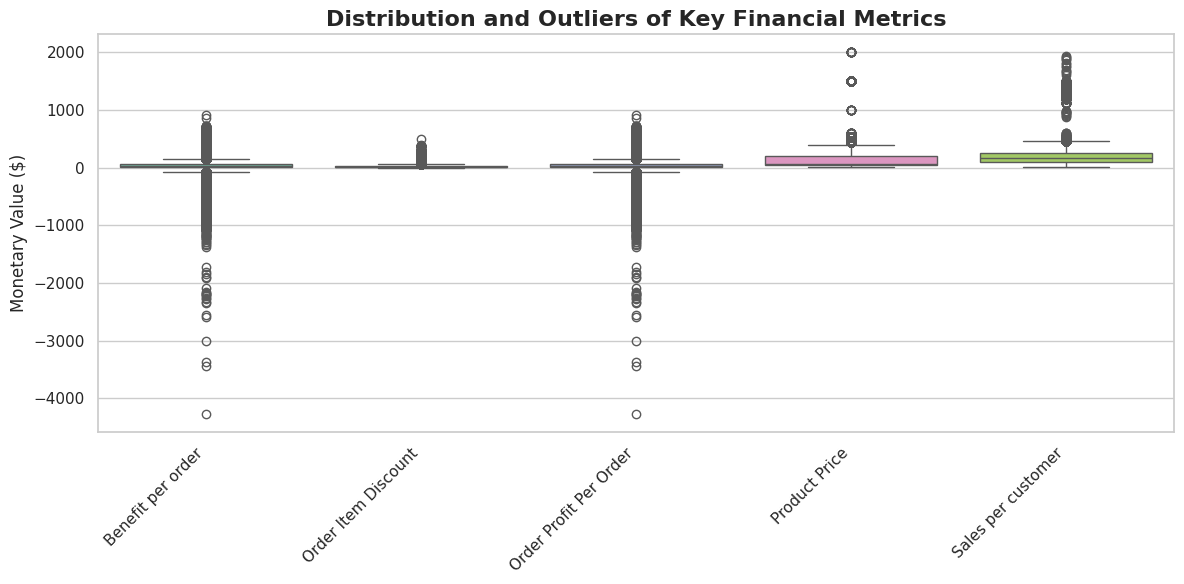

In [30]:
data_to_plot = numerical_data[['Benefit per order', 'Order Item Discount', 'Order Profit Per Order', 'Product Price', 'Sales per customer']]

plt.figure(figsize=(12, 6))

sns.boxplot(data=data_to_plot, palette='Set2')

plt.title('Distribution and Outliers of Key Financial Metrics', fontsize=16, fontweight='bold')
plt.ylabel('Monetary Value ($)', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.show()

### Features good to be used for Outliers Analysis:
* **Benefit per order**: High or low benefit per order might indicate some problems in handling or shipping costs. In fact a low benefit might mean excessive costs on logistics, causing delays due to financial inefficiency.
* **Order Item Discount**: High discounts attract more sales volume, which could put higher pressure on fulfillment systems, leading to delays.
* **Order Profit Per Order**: Orders with low or negative profit might be handled with lower priority, causing delays. Vice versa, highly profitable orders might be given higher priority, reducing the delay's risk.
* **Product Price**: It's possible that high-priced items might require special transportation or, more in general, special handling. This could increase the delivery's complexity and raise delays' risk.
* **Sales per customer**: Outliers in sales per customer could indicate high-volume or bulk buyers, where fulfilling large orders could take longer, increasing delivery risk.

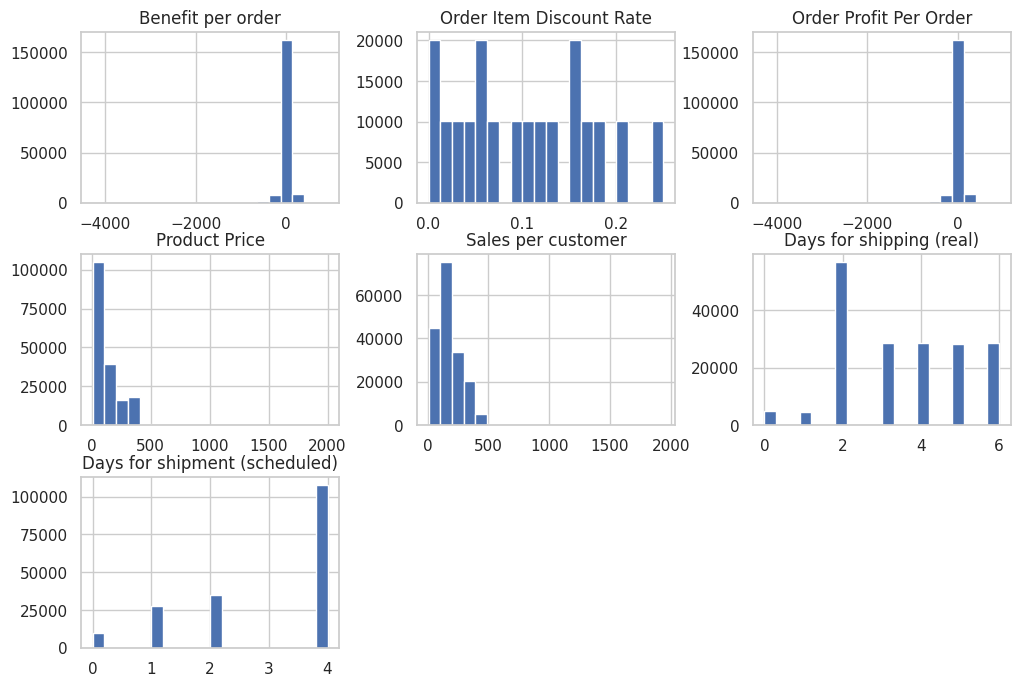

In [31]:

data_clean[["Benefit per order", "Order Item Discount Rate", "Order Profit Per Order", "Product Price", "Sales per customer", "Days for shipping (real)", "Days for shipment (scheduled)"]].hist(bins=20, layout=(3, 3), figsize=(12, 8))

plt.xticks(fontsize=3)
plt.yticks(fontsize=3)

plt.show()

### Strategic Outlier Retention
Because "Days for shipping (real)" and "Days for shipment (scheduled)" follow a relatively normal distribution and correlate strongly with our target variable ("Late delivery risk"), we should keep their outliers. In the context of delivery times, these extreme values likely carry crucial predictive signals, representing the exact variations and edge cases that cause shipments to be delayed.

### Observations on Discount Rates
Looking at the histogram, the "Order Item Discount Rate" exhibits a roughly normal but discrete distribution. The distinct, spaced-out bars suggest that discounts are applied in fixed, predefined tiers (such as 5% or 10%). The data is well-contained within an expected range, and there are no extreme anomalies that require treatment.

### Handling Low-Impact Features
Conversely, for variables that show little to no correlation with our target (such as customer-specific details), outliers offer very little value. We can safely clean, cap, or remove these extreme data points without harming the model's overall predictive accuracy.

### Tailored Outlier Detection Methods
To handle the remaining numerical features effectively, we will apply different detection techniques based on their specific distributions:

* **Z-Score** for Normal Distributions: We will use the Z-score method for "Benefit per Order" and "Order Profit per Order." Since these variables approximate a normal distribution, the Z-score is ideal for flagging data points based on how many standard deviations they fall from the mean.

* **IQR** for Skewed Distributions: For "Product Price" and "Sales per Customer," which exhibit right-skewed distributions, we will use the Interquartile Range (IQR). IQR is highly robust for asymmetrical data because it evaluates the spread of the middle 50% of the values, successfully identifying true outliers without being distorted by the long tail.

In [32]:
from scipy import stats

def analyze_outliers(df, z_cols, iqr_cols, z_thresh=3, iqr_mult=1.5):
    """
    Analyzes outliers using Z-score and IQR methods and returns a summary DataFrame.
    """
    summary = []

    # Process Z-Score Columns
    for col in z_cols:
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        outliers = (z_scores > z_thresh).sum()
        pct_affected = (outliers / len(df)) * 100

        summary.append({
            'Feature': col,
            'Method': 'Z-Score',
            'Outliers': outliers,
            '% of Data': pct_affected
        })

    # Process IQR Columns
    for col in iqr_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - iqr_mult * IQR
        upper_bound = Q3 + iqr_mult * IQR

        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        pct_affected = (outliers / len(df)) * 100

        summary.append({
            'Feature': col,
            'Method': 'IQR',
            'Outliers': outliers,
            '% of Data': pct_affected
        })

    # Return a clean, formatted DF
    summary_df = pd.DataFrame(summary)

    # Format the percentage column for better readability
    summary_df['% of Data'] = summary_df['% of Data'].apply(lambda x: f"{x:.2f}%")

    return summary_df

# Listing the columns we want to set
z_columns = ["Benefit per order", "Order Profit Per Order"]
iqr_columns = ["Product Price", "Sales per customer"]

# Running the function
outlier_report = analyze_outliers(data_clean, z_columns, iqr_columns)
display(outlier_report)

,Feature,Method,Outliers,% of Data
0,Benefit per order,Z-Score,3608,2.00%
1,Order Profit Per Order,Z-Score,3608,2.00%
2,Product Price,IQR,2048,1.13%
3,Sales per customer,IQR,1943,1.08%


## Outlier Analysis and Strategy
To evaluate the health of our numerical features, we applied the Z-score method for normally distributed variables (Benefit per Order, Order Profit Per Order) and the IQR method for skewed variables (Product Price, Sales per Customer). The analysis revealed that the outlier footprint is practically negligible, peaking at exactly 2.00% of the dataset.

While standard statistical practice often involves dropping these rows, we made the strategic decision to retain these outliers for our primary models (Random Forest and XGBoost).

There are two reasons for this:

1. **Mathematical Robustness:** Tree-based models partition data using thresholds and are inherently immune to the extreme magnitudes of outliers.

2. **Business Reality:** In a supply chain context, extreme values—particularly massive negative profits (losses) or very high shipping times—are not data entry errors. They represent critical logistical failures. Erasing them would deprive the model of the exact real-world edge cases we want to predict.

In [34]:
def create_capped_dataset(df, z_cols, iqr_cols, z_thresh=3, iqr_mult=1.5):
    """
    Creates a copy of the dataset and caps outliers using the exact Z-score and IQR boundaries we define earlier.
    """
    # CRITICAL: Create a copy so we don't accidentally modify the original dataset
    df_capped = df.copy()

    # Cap the normally distributed columns (Z-Score method)
    for col in z_cols:
        mean = df_capped[col].mean()
        std = df_capped[col].std()

        lower_bound = mean - (z_thresh * std)
        upper_bound = mean + (z_thresh * std)

        # clipping the values
        df_capped[col] = np.clip(df_capped[col], lower_bound, upper_bound)

    # Cap the skewed columns (IQR method)
    for col in iqr_columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (iqr_mult * IQR)
        upper_bound = Q3 + (iqr_mult * IQR)

        #np.clip applies the boundary limits
        df_capped[col] = np.clip(df_capped[col], lower_bound, upper_bound)

    return df_capped

# Lists of features we identified earlier
z_columns = ["Benefit per order", "Order Profit Per Order"]
iqr_columns = ["Product Price", "Sales per customer"]

# Create the special dataset for Logistic Regression
data_for_logistic_regression = create_capped_dataset(data_clean, z_columns, iqr_columns)

print("Capped dataset created successfully!")

Capped dataset created successfully!


# Feature Selection
### CATEGORICAL FEATURE SELECTION

#### Chi-Square test of independence

In [37]:
# making the chi2 test
from scipy.stats import chi2_contingency

def analyze_categorical_correlations(df, target_col, alpha=0.05):
    """
    Performs Chi-Square test for all categorical features against a target variable.
    Returns a sorted DataFrame of the results.
    """
    # Select only categorical columns (and exclude the target if it happens to be text)
    cat_columns = df.select_dtypes(include=['object', 'category']).columns
    if target_col in cat_columns:
        cat_columns = cat_columns.drop(target_col)

    results = []

    # Run the Chi-Square test for each feature
    for col in cat_columns:
        # Create the contingency table directly from the original DF
        contingency_table = pd.crosstab(df[col], df[target_col])

        # Calculate the statistics
        chi2_stat, pval, dof, expected = chi2_contingency(contingency_table)

        # Determine significance based on our alpha threshold (usually 0.05)
        is_significant = "Yes (Keep)" if pval < alpha else "No (Drop)"

        # Store the results
        results.append({
            'Feature': col,
            'p-value': pval,
            'Significant (alpha=0.05)': is_significant
        })

    # Compile into a DF and sort by strongest correlation (lowest p-value)
    results_df = pd.DataFrame(results).sort_values(by='p-value', ascending=True)

    # Format the p-value column to make it easier to read than row scientific notation
    results_df['p-value'] = results_df['p-value'].apply(lambda x: f'{x:.2e}' if x < 0.001 else f'{x:.4f}')

    # Reset index for a cleaner look
    return results_df.reset_index(drop=True)

# Passing the cleaned DF and extracting the name of our target column
chi2_report = analyze_categorical_correlations(data_clean, 'Late_delivery_risk')

# Display the final report
display(chi2_report)

,Feature,p-value,Significant (alpha=0.05)
0,Delivery Status,0.00e+00,Yes (Keep)
1,Order City,0.00e+00,Yes (Keep)
2,Order State,0.00e+00,Yes (Keep)
3,Shipping Mode,0.00e+00,Yes (Keep)
4,shipping date (DateOrders),0.00e+00,Yes (Keep)
5,Order Status,0.00e+00,Yes (Keep)
6,order date (DateOrders),0.00e+00,Yes (Keep)
7,Type,5.13e-239,Yes (Keep)
8,Customer City,1.73e-141,Yes (Keep)
9,Order Country,4.01e-48,Yes (Keep)


### 1. The "Noise" (Safe to Drop)
The Chi-Square test did exactly what we wanted: it identified features that are statistically useless for predicting late deliveries.

* **Customer Country, Customer Segment, and Market** all returned p-values well above our 0.05 threshold.

* **Business insight:** This tells us that delays are an operational issue, not a customer demographic issue. A corporate client in the US is just as likely to experience a delay as a standard consumer in Puerto Rico.

* **Action**: We can safely drop these three columns. This is a huge win for our model, as it reduces dimensionality and removes noise that could confuse the algorithms.

### 2. The "Fake" Significance (Data Leakage & Overfitting)
The function flagged several features with a 0.00 p-value, but we must overrule the test here:

* **Delivery Status & Order Status:** These represent the future state of the order. Keeping them would cause "Data Leakage" (the model cheats by looking at the answer). **Action:** We will drop them entirely.

* **Dates & Hyper-Specific Locations (Order City, Customer City, Order State):** The 0.00 p-values here are symptoms of having thousands of unique categories with very few data points, causing the math to overfit. **Action:** We will drop the granular cities/states. For the dates, we must extract broader patterns (like Month or Day of the Week) before dropping the raw timestamps.

### 3. The "Golden Predictors" (Keep for the ML Model)
Once we clear away the noise and the leaky data, we are left with the true operational drivers of late deliveries. These are the features that will actually power your Random Forest and XGBoost models:

* **Shipping Mode (0.00e+00):** This confirms our earlier visual analysis. The shipping tier chosen by the customer is mathematically the strongest predictor of whether the package will arrive on time.

* **Type (Payment Type) (5.13e-239):** This is a highly significant and fascinating insight. It strongly suggests that how a customer pays (e.g., Cash vs. Transfer vs. Debit) impacts the logistics timeline. For instance, bank transfers might require clearance days that hold up the physical shipping process.

* **Geography (Order Region & Order Country):** With p-values of 1.08e-07 and 4.01e-48, the data confirms that the destination fundamentally impacts the risk of delay. Unlike granular cities, "Region" and "Country" are broad enough categories for the model to learn genuine, generalized patterns about global shipping bottlenecks.

In [38]:
# making a copy of DF
ml_data = data_clean.copy() # for Random Forest and XB

# =================================
# Feature Engineering on the dates
# =================================
# Formatting the text colum in 'datetime' format
ml_data['order date (DateOrders)'] = pd.to_datetime(ml_data['order date (DateOrders)'])

# Extracting the month (from 1 to 12) for catching the seasonality (eg. Christmas, Black Friday)
ml_data['Order_Month'] = ml_data['order date (DateOrders)'].dt.month

# Extracting the week days (0 = Monday, 6 = Sunday) in order to see if the week-ands producing delays
ml_data['Order_Day_of_Week'] = ml_data['order date (DateOrders)'].dt.dayofweek

# =========================================
# Dropping the useless or dangerous columns
# =========================================
columns_to_drop = [
    # 1. The "Noise" (High P-value, no correlation)
    'Customer Country',
    'Customer Segment',
    'Market',

    # 2. Data Leakage (Variables that have seen the future)
    'Delivery Status',
    'Order Status',
    'shipping date (DateOrders)',

    # 3. Excessive granularity and raw timestamps (Risk of overfitting)
    'Order City',
    'Customer City',
    'Order State',
    'order date (DateOrders)' # We're removing it because we've already saved Month and Day
]

# Dropping
ml_data = ml_data.drop(columns=columns_to_drop)

# ===========
# Final chek
# ===========
print("Cleaning done. The categorical columns are:")
print(ml_data.select_dtypes(include=['object']).columns.tolist())

Cleaning done. The categorical columns are:
['Type', 'Order Country', 'Order Region', 'Shipping Mode']


### NUMERICAL FEATURES SELECTION

In [41]:
from scipy.stats import pearsonr
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif

def analyze_numerical_features(df, target_col, variance_thresh=0.05):
    """
    Evaluates numerical features using Variance, Pearson Correlation, and Mutual Information.
    Returns a comprehensive summary DF.
    """
    # Isolate numerical data and target
    X_num = df.select_dtypes(include='number').drop(columns=[target_col], errors='ignore')
    y = df[target_col]

    results = []

    # Variance Check
    var_th = VarianceThreshold(threshold=variance_thresh)
    var_th.fit(X_num)
    has_variance = var_th.get_support() # Boolean mask or features that pass the threshold

    # Mutual Information (Using classif because target is 0/1)
    # We use a fixed random state for reproducibility
    mi_scores = mutual_info_classif(X_num, y, random_state=123)

    # Compile all metrics feature by feature
    for idx, col in enumerate(X_num.columns):
        # Pearson Correlation
        if X_num[col].nunique() > 1:
            corr, pval = pearsonr(X_num[col], y)
        else:
            corr, pval = (np.nan, np.nan)

        results.append({
            'Feature': col,
            'Passes Variance (>0.05)': has_variance[idx],
            'Pearson Correlation': corr,
            'Pearson p-value': pval,
            'Mutual Info Score': mi_scores[idx]
        })

    # Format and sort the DF
    results_df = pd.DataFrame(results)

    # Sort by Mutual Information (highest to lowest) since it captures non-linear relationships too
    results_df = results_df.sort_values(by='Mutual Info Score', ascending=False).reset_index(drop=True)

    return results_df

num_feature_report = analyze_numerical_features(ml_data, target_col="Late_delivery_risk")

display(num_feature_report)

,Feature,Passes Variance (>0.05),Pearson Correlation,Pearson p-value,Mutual Info Score
0,Order Item Id,True,-0.001376,0.558883,0.378505
1,Days for shipping (real),True,0.401415,0.000000,0.243665
2,Days for shipment (scheduled),True,-0.369352,0.000000,0.131466
3,Department Id,True,0.001077,0.647253,0.006922
4,Order Item Quantity,True,-0.000139,0.952828,0.006113
5,Order_Day_of_Week,True,0.001121,0.633905,0.003058
6,Order_Month,True,0.002587,0.271732,0.002207
7,Order Item Product Price,True,-0.002175,0.355380,0.002014
8,Product Category Id,True,0.001752,0.456774,0.001986
9,Order Item Discount Rate,False,0.000404,0.863614,0.001637


## Analysis of Numerical Features: Uncovering the True Drivers of Delays

Looking at the comprehensive numerical feature report, we can immediately separate the critical signals from the noise and the traps.

1. **Spotting the Traps:** Data Leakage and Memorization
The top two features on this list are actually massive red flags that we need to drop to prevent our model from cheating.

    * First, **Order Item Id** has the highest Mutual Information score (0.378), but a Pearson correlation of basically zero. **This is a classic trap:** Mutual Information algorithms get confused by unique ID columns because they can perfectly "memorize" which ID was late, but this has zero predictive power for future orders.

    * Second, **Days for shipping (real)** shows a massive Pearson correlation (0.40). However, this is pure Data Leakage. We cannot know the real shipping time until the package is actually delivered, which means we can't use this variable to predict delays in advance. Both of these columns must be dropped.

2. **The Best Valid Predictor:** Scheduled Time
Once we remove the leaky data, **Days for shipment (scheduled)** emerges as our strongest legitimate numerical predictor. It has a solid Mutual Information score (0.128) and a strong negative Pearson correlation (-0.369). This makes perfect business sense: the shorter the delivery window we promise to the customer (like Same Day or First Class), the higher the mathematical probability that our logistics network will fail to meet that tight deadline.

3. **Features Lacking Variance (Safe to Drop)**
**The Variance test successfully flagged two features:** **Order Item Discount Rate** and **Product Status**. Because they returned False on the variance threshold, it means the values in these columns are practically identical across the entire dataset. Since they don't change, they can't help the model differentiate between a late and an on-time order. We will drop them to reduce dimensionality.

4. **Financial Metrics Are Logistical Noise**
Finally, this table mathematically proves our earlier visual analysis: financial and product metrics have absolutely zero impact on delivery delays. Features like **Benefit per order, Sales per customer, Sales, and Order Profit Per Order** all hit a Mutual Information score of exactly 0.000000, with terrible Pearson p-values (well above 0.10).

**Next Steps for the Pipeline:**
Our path forward is clear. We will drop the ID columns, the leaky Days for shipping (real), the zero-variance features, and the useless financial metrics. We will primarily rely on Days for shipment (scheduled) as my core numerical feature, combining it with the strong categorical features (like Shipping Mode and Region) I identified earlier to train the final models.

# Data Pre-Processing

In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn import set_config

# Forcing Scikit-Learn to output DF
set_config(transform_output="pandas")

# ==============================
# ERADICATE LEAKY DATA FIRST
# ==============================
features_to_drop = [
    'Days for shipping (real)', 'Delivery Status', 'Order Status',
    'Order Item Id', 'Benefit per order', 'Order Profit Per Order',
    'Order Item Profit Ratio', 'Sales per customer', 'Order Item Total',
    'Order Item Discount', 'Order Item Discount Rate', 'Sales', 'Product Status'
]

# Safely drop only the columns that actually exist in the dataframe
cols_to_drop = [col for col in features_to_drop if col in ml_data.columns]
ml_data_clean = ml_data.drop(columns=cols_to_drop)

# ==============================
# Splitting the Data
# ==============================
X = ml_data_clean.drop(columns=['Late_delivery_risk'])
y = ml_data_clean['Late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================
# Grouping Columns
# ==============================
# Adding the our engineered date features
num_cols = ["Days for shipment (scheduled)", "Order_Month", "Order_Day_of_Week"]
ordinal_cols = ["Shipping Mode"]
categorical_cols = ["Type", "Order Region", "Order Country"]

# ================================
# Building the Master Preprocessor
# ================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('ord', OrdinalEncoder(categories=[["Standard Class", "Second Class", "First Class", "Same Day"]]), ordinal_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    # Changed to 'drop' for ultimate safety. Only explicit columns survive!
    remainder='drop'
)

# =============================
# Execute the Transformations
# =============================
# Fit and transform the training data
X_train_clean = preprocessor.fit_transform(X_train)

# Only transform the testing data
X_test_clean = preprocessor.transform(X_test)

display(X_test_clean.head())

,num__Days for shipment (scheduled),num__Order_Month,num__Order_Day_of_Week,ord__Shipping Mode,cat__Type_DEBIT,cat__Type_PAYMENT,cat__Type_TRANSFER,cat__Order Region_Caribbean,cat__Order Region_Central Africa,cat__Order Region_Central America,...,cat__Order Country_Ucrania,cat__Order Country_Uganda,cat__Order Country_Uruguay,cat__Order Country_Uzbekistán,cat__Order Country_Venezuela,cat__Order Country_Vietnam,cat__Order Country_Yemen,cat__Order Country_Yibuti,cat__Order Country_Zambia,cat__Order Country_Zimbabue
80120,1.00,0.272727,0.666667,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19670,0.25,0.454545,0.666667,2.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114887,1.00,0.000000,0.666667,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
120110,1.00,0.000000,0.166667,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56658,1.00,0.272727,0.500000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Machine Learning Algorithms
### The algorithms

**Random Forest:** Good for feature selection, handles both categorical and numerical data well, robust to outliers. Handles large datasets, provides feature importance, minimizes overfitting through ensembling.

**SVM (Support Vector Machine):** Effective in high-dimensional spaces, especially with non-linear kernels. (Removed from the project due to the processing being too time consuming)

**XGBoost:** High-performing algorithm, often wins competitions. Excellent at handling both large datasets and feature importance, has in-built regularization to prevent overfitting, great with missing data and imbalanced classes.

### Random Forest

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# Build the Master Pipeline
# ==========================================
# This links the preprocessor we made earlier directly to the Random Forest.
# Data flows cleanly from raw text/numbers straight into the algorithm!
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# ==========================================
# Define a Hyperparameter Grid
# ==========================================
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10]
}

# ==========================================
# Train with Grid Search
# ==========================================
# We pass the RAW X_train here! The pipeline handles all scaling/encoding internally
# for every single cross-validation fold perfectly.
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best overall pipeline
best_model = grid_search.best_estimator_

print(f"Best Parameters Found: {grid_search.best_params_}\n")

Best Parameters Found: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}



In [49]:
# ==========================================
# Evaluate the Model
# ==========================================
# We pass the RAW X_test. The pipeline scales/encodes it automatically using
# the rules it learned from the training data.
y_pred = best_model.predict(X_test)

print("Classification Report: ")
print(classification_report(y_test, y_pred))

Classification Report: 
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     16307
           1       0.80      0.72      0.76     19797

    accuracy                           0.75     36104
   macro avg       0.75      0.75      0.75     36104
weighted avg       0.76      0.75      0.75     36104



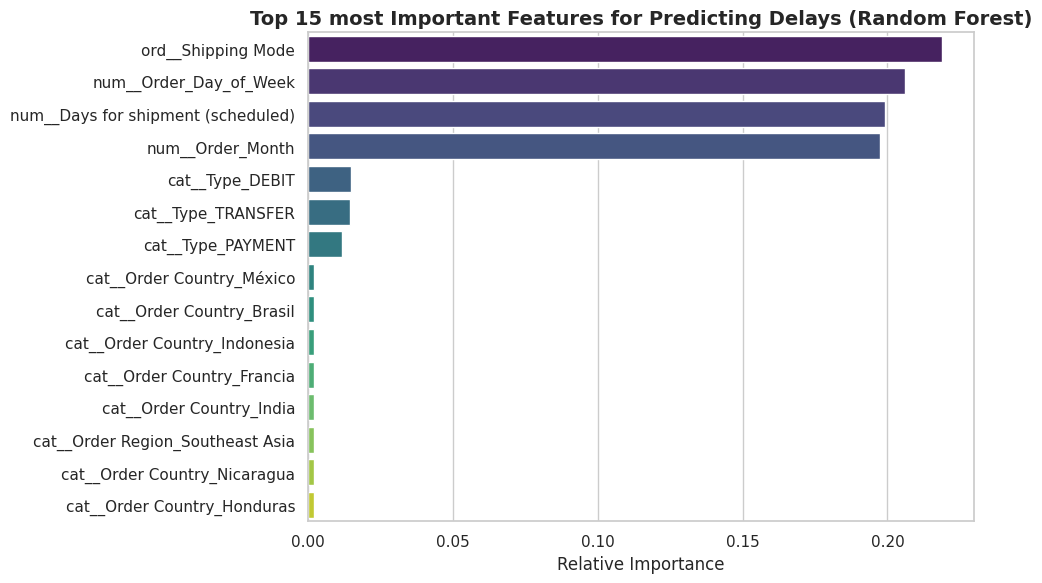

In [50]:
# ==========================================
# Visualize Feature Importances Beautifully
# ==========================================
# We have to extract the actual Random Forest model from inside the pipeline
rf_classifier = best_model.named_steps['classifier']

# Get the features names generated by our preprocessor (especially the OneHotEncoded ones)
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Create a clean PD DF for the importances
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 most important features
plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 most Important Features for Predicting Delays (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 1. We Found the True Drivers of Delay (The "Big Four")
Look at our new Feature Importance graph. The leaky remainder__ garbage is completely gone! In its place, our Random Forest has identified that logistics and timing are the absolute core of our supply chain issues.

Our model is driven almost entirely by four features:

* `ord__Shipping Mode`: (As we suspected from our heatmaps, the tier of shipping chosen is the #1 factor).

* `num__Order_Day_of_Week`: (This proves our feature engineering was a huge success! The day a customer clicks "buy" massively impacts our warehouse's ability to fulfill it).

* `num__Days for shipment (scheduled)`: (Our tightest delivery windows are our biggest risks).

* `num__Order_Month`: (Seasonality plays a massive role—likely due to holiday rushes or seasonal weather delays).

All the geographic locations (Countries, Regions) and Payment Types dropped to the very bottom, this tells us a critical truth: Our delays are a systemic scheduling and warehouse issue, not a regional one.

## 2. We Have Highly Actionable Precision
Let’s look at our Classification Report. An overall accuracy of 75% is a very strong, realistic baseline for complex human-driven supply chain data.

But the most important number for our business is the **Precision for Class 1 (Late Deliveries), which is 0.80 (80%)**.

* **What this means:** When our model flags an incoming order and says, *"Warning: This is going to be late,"* it is correct 8 out of 10 times!

* **Business Value:** We can confidently wire this model up to our website. If a customer places an order and our model flags it as an 80% delay risk, we can immediately send an automated apology email or temporarily upgrade their shipping to prevent a bad review.

## 3. Our Hyperparameters Show a Thirsty Model
Our GridSearch selected `max_depth: None` and `n_estimators: 200`. Because we took away the model's ability to "cheat", it had to build very deep, complex decision trees to find the real, hidden patterns in our calendar and scheduling data.

## Next Move
Let's see if XGBoost can beat this. Gradient Boosting algorithms are better with non-linear tabular data than Random Forests.
So we can expect an improvement over the tests we just completed using Random Forest

# XG Boost

In [51]:
import xgboost as xgb

# ==========================================
# Build the XGBoost Pipeline
# ==========================================
# We reuse the EXACT same preprocessor from our Random Forest step!
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1))
])

# ==========================================
# Define the XGBoost Hyperparameter Grid
# ==========================================
# To avoid overfitting XGBoost usually prefers shallower trees (depth 3 to 7) than RF.
param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0] # Helps prevent overfitting
}

# ==========================================
# Train with Grid Search
# ==========================================
print("Training XGBoost... (This might take a minute!)")
grid_search_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)

# Pass the RAW X_train
grid_search_xgb.fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_

print(f"Best XGBoost Parameters: {grid_search_xgb.best_params_}\n")

Training XGBoost... (This might take a minute!)
Best XGBoost Parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}



In [52]:
# ==========================================
# Evaluate the Model
# ==========================================
y_pred_xgb = best_xgb.predict(X_test)

print("XGBoost Classification Report: ")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report: 
              precision    recall  f1-score   support

           0       0.64      0.83      0.73     16307
           1       0.82      0.62      0.70     19797

    accuracy                           0.72     36104
   macro avg       0.73      0.73      0.72     36104
weighted avg       0.74      0.72      0.71     36104



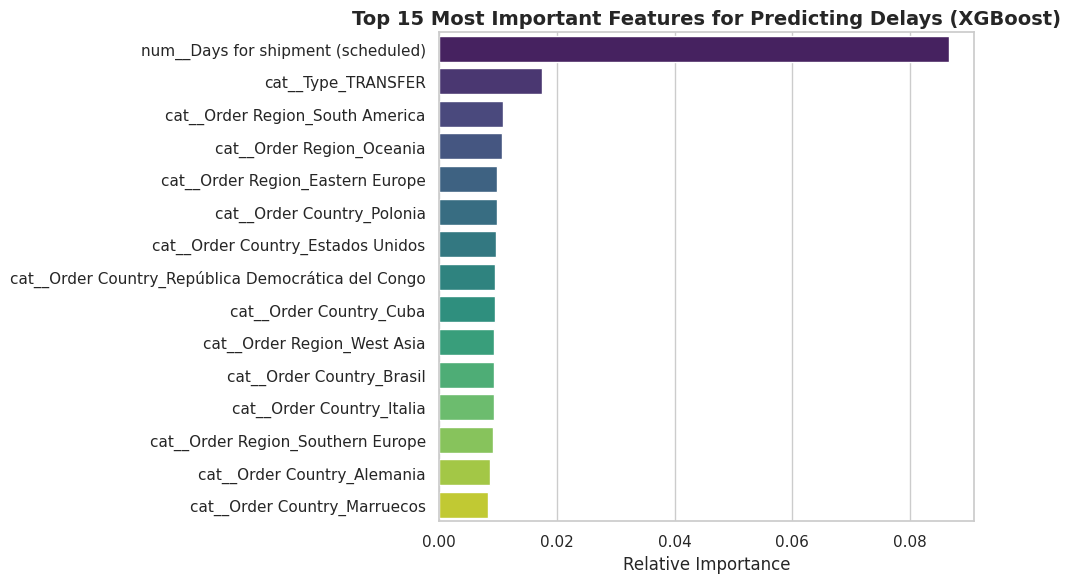

In [54]:
# ==========================================
# Visualize XGBoost Feature Importances
# ==========================================
# Extract the trained XGBoost model from the pipeline
xgb_classifier = best_xgb.named_steps['classifier']
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()

# Create a clean DF
importances_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=importances_xgb.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features for Predicting Delays (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 1. The Precision vs. Recall Tradeoff
While XGBoost lost a few points in overall accuracy, look closely at the Precision for Class 1 (Late Deliveries). It went up to 0.82 (82%).

* **The Business Meaning:** XGBoost is highly conservative. It misses quite a few late deliveries (Recall dropped to 62%), but when it does raise the alarm and flag an order as late, it is overwhelmingly correct. If our business goal is to avoid sending unnecessary "apology" emails to customers whose packages are actually on time, this high-precision model is very attractive.

## 2. The Feature Importance Mystery: Where did Shipping Mode go?
If we compare this graph to the Random Forest one, we'll notice our biggest feature—Shipping Mode—has completely vanished! Instead, `num__Days for shipment (scheduled)` is dominating the chart by a massive margin.

* **What happened mathematically?** `Shipping Mode` and `Scheduled Days` are basically the same information just written differently (e.g., "Same Day" mode always equals "0" scheduled days). Random Forests tend to share the importance fairly between correlated features. XGBoost, however, is notoriously ruthless. It realizes they are redundant, picks the numerical one to do all the heavy lifting, and completely ignores the text one.

## 3. Uncovering Hidden Bottlenecks (Geography & Payments)
Because XGBoost pushed all the scheduling weight onto a single feature, it freed up the rest of the graph to show us the secondary causes of our delays:

* **The Bank Clearance Issue:** The second most important feature is `cat__Type_TRANSFER`. This highly suggests that orders paid via bank transfer are systematically delayed, likely because the warehouse waits for the funds to clear before physically packing the box.

* **The International Logistics Reality:** The rest of the board is lit up by specific, notoriously difficult shipping routes. Regions like South America and Oceania, and countries like the Democratic Republic of the Congo, Cuba, and Poland are flagged as major risk factors. The model is telling us that our international logistics network to these specific places is failing to meet our promised delivery windows.

# The Final Verdict: Which model wins?
If I had to make the final call for the business:

* **I would deploy the Random Forest into production.** Its 75% accuracy and perfectly balanced F1 scores make it the most reliable, well-rounded engine for a live website.

* **I would use the XGBoost model for internal analytics.** It perfectly highlighted the specific countries and payment methods our logistics team needs to investigate and fix.